### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import nltk
from nltk.corpus import stopwords

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
from wordcloud import WordCloud

### Step 2: Load Dataset

In [6]:
df = pd.read_csv('./data/flipkart_data.csv')

In [7]:
df.head()

,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5


In [11]:
stop_words = stopwords.words('english')

In [12]:
def preprocess_reviews_stopwords(df):
    df['review'] = df['review'].str.lower()
    df['review'] = df['review'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
    df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)
    return df

In [13]:
df_cleaned = preprocess_reviews_stopwords(df)

In [14]:
df.head()

,review,rating,sentiment
0,nice produt. like design lot. easy carry. and....,5,1
1,awesome sound....very pretty see nd sound qual...,5,1
2,awesome sound quality. pros 7-8 hrs battery li...,4,1
3,think good product per quality also design qui...,5,1
4,awesome bass sound quality good bettary long l...,5,1


### Step 3: Exploring Data

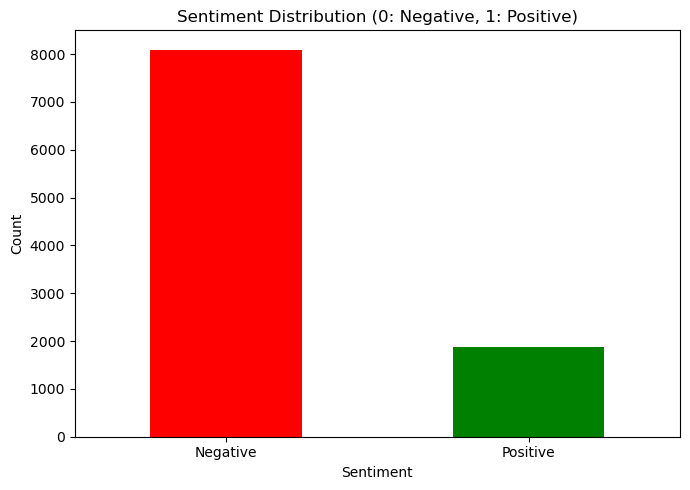

In [25]:
plt.figure(figsize=(7,5))
df['sentiment'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Sentiment Distribution (0: Negative, 1: Positive)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Negative', 'Positive'], rotation=0)
plt.tight_layout()

In [40]:
positive_reviews = df_cleaned[df_cleaned['sentiment'] == 1]['review']
positive_text = ' '.join(positive_reviews)

In [54]:
wordcloud = WordCloud(width=800, height=400, colormap=plt.cm.rainbow, background_color='black').generate(positive_text)

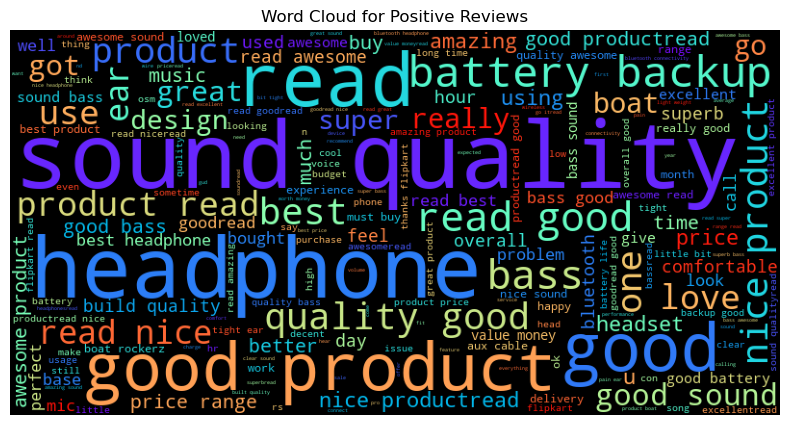

In [55]:
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, cmap=plt.cm.Blues)
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.tight_layout()

### Step 4: Feature Engineering

In [56]:
vectorizer = TfidfVectorizer(max_features=5000)

In [57]:
X = vectorizer.fit_transform(df_cleaned['review'])
y = df_cleaned['sentiment']

### Step 5: Preparing Data

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Step 6: Training Data

In [59]:
model = DecisionTreeClassifier(random_state=42)

In [60]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Step 7: Evaluate Data

In [61]:
y_pred = model.predict(X_test)

In [62]:
accuracy = accuracy_score(y_test, y_pred)

In [63]:
conf_matrix = confusion_matrix(y_test, y_pred)

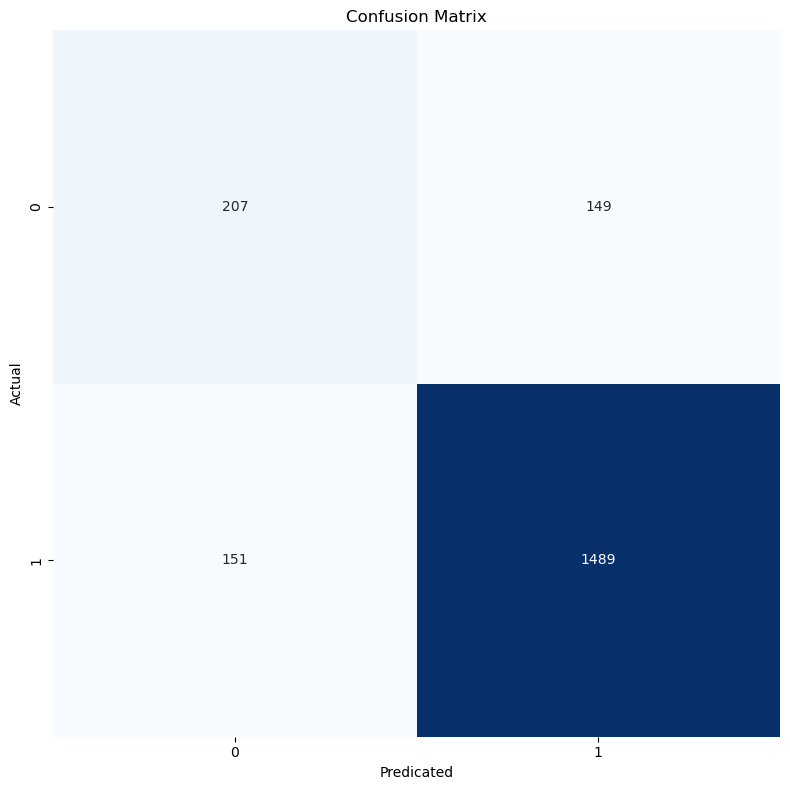

In [74]:
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=plt.cm.Blues, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicated')
plt.ylabel('Actual')
plt.tight_layout()

In [82]:
print('test accuracy:', round(accuracy, 3))

test accuracy: 0.85
